In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_c = pd.read_csv('child.csv')
df_p = pd.read_csv('parent.csv')

In [3]:
len(df_c), len(df_p)

(1001, 1001)

In [4]:
# change the age records with only extract numbers
df_c['user_age'] = df_c['user_age'].str.extract('(\d+)')
df_p['user_age'] = df_p['user_age'].str.extract('(\d+)')

In [5]:
# Convert age keys to integers for correct numeric sorting
age_child = {int(k): v for k, v in df_c['user_age'].value_counts().to_dict().items()}
age_parent = {int(k): v for k, v in df_p['user_age'].value_counts().to_dict().items()}

# Sort by age (numeric)
age_child = dict(sorted(age_child.items()))
age_parent = dict(sorted(age_parent.items()))

# Print age distribution
print("Child Age Distribution:")
total_children = sum(age_child.values())
for age, count in age_child.items():
    print(f"Age {age}: {count} children")
print(f"Total children: {total_children}")

print("\nParent Age Distribution:")
total_parents = sum(age_parent.values())
for age, count in age_parent.items():
    print(f"Age {age}: {count} parents")
print(f"Total parents: {total_parents}")

Child Age Distribution:
Age 2: 11 children
Age 3: 3 children
Age 4: 4 children
Age 5: 12 children
Age 6: 26 children
Age 7: 38 children
Age 8: 56 children
Age 9: 82 children
Age 10: 160 children
Age 11: 136 children
Age 12: 123 children
Age 13: 215 children
Age 14: 67 children
Age 15: 33 children
Age 16: 10 children
Age 17: 8 children
Age 18: 16 children
Total children: 1000

Parent Age Distribution:
Age 1: 1 parents
Age 2: 41 parents
Age 3: 9 parents
Age 4: 24 parents
Age 5: 49 parents
Age 6: 74 parents
Age 7: 87 parents
Age 8: 129 parents
Age 9: 75 parents
Age 10: 123 parents
Age 11: 45 parents
Age 12: 59 parents
Age 13: 70 parents
Age 14: 25 parents
Age 15: 21 parents
Age 16: 28 parents
Age 17: 10 parents
Age 18: 130 parents
Total parents: 1000


/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_88376/2552343309.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


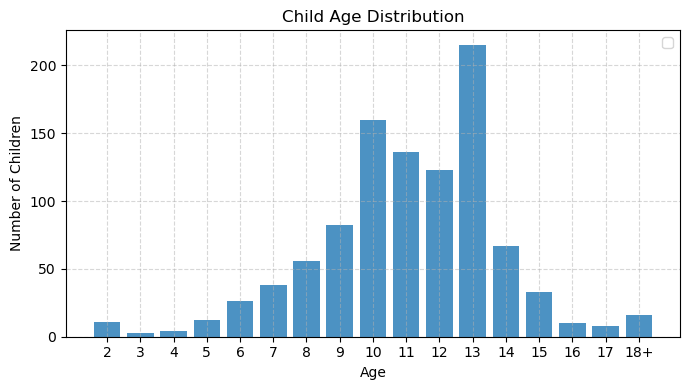

/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_88376/2552343309.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


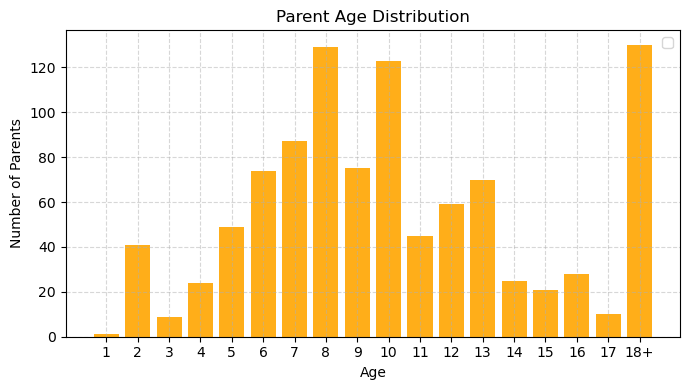

In [6]:
# Convert to pandas Series for plotting
child_series = pd.Series(age_child).sort_index()
parent_series = pd.Series(age_parent).sort_index()

# Rename 18 to '18+' and convert all indices to string for plotting
child_series.index = child_series.index.map(lambda x: '18+' if x == 18 else str(x))
parent_series.index = parent_series.index.map(lambda x: '18+' if x == 18 else str(x))

# Plot child age distribution
plt.figure(figsize=(7, 4))
plt.bar(child_series.index, child_series.values, alpha=0.8)
# plt.plot(child_series.index, child_series.values, marker='o', linestyle='-', label='Child Age Distribution')
plt.title('Child Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Children')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('child_age_distribution.png', dpi=300)
plt.show()

# Plot parent age distribution
plt.figure(figsize=(7, 4))
plt.bar(parent_series.index, parent_series.values, alpha=0.9, color='orange')
# plt.plot(parent_series.index, parent_series.values, marker='o', linestyle='-', label='Parent Age Distribution', color='red')
plt.title('Parent Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Parents')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('parent_age_distribution.png', dpi=300)
plt.show()

In [30]:
age_child.get(2, 0)

11

In [31]:
# Group into different ages: 0-5
age_groups = ["0-5", "6-12", "13-17"]
children_05 = age_child.get(0, 0) + age_child.get(1, 0) + age_child.get(2, 0) + age_child.get(3, 0) + age_child.get(4, 0) + age_child.get(5, 0)
children_612 = age_child.get(6, 0) + age_child.get(7, 0) + age_child.get(8, 0) + age_child.get(9, 0) + age_child.get(10, 0) + age_child.get(11, 0)
children_1317 = age_child.get(12, 0) + age_child.get(13, 0) + age_child.get(14, 0) + age_child.get(15, 0) + age_child.get(16, 0) + age_child.get(17, 0)

parent_05 = age_parent.get(0, 0) + age_parent.get(1, 0) + age_parent.get(2, 0) + age_parent.get(3, 0) + age_parent.get(4, 0) + age_parent.get(5, 0)
parent_612 = age_parent.get(6, 0) + age_parent.get(7, 0) + age_parent.get(8, 0) + age_parent.get(9, 0) + age_parent.get(10, 0) + age_parent.get(11, 0)
parent_1317 = age_parent.get(12, 0) + age_parent.get(13, 0) + age_parent.get(14, 0) + age_parent.get(15, 0) + age_parent.get(16, 0) + age_parent.get(17, 0)

print(f"For children 0-5: {children_05}, 6-12: {children_612}, 13-17: {children_1317}")
print(f"For parents 0-5: {parent_05}, 6-12: {parent_612}, 13-17: {parent_1317}")

For children 0-5: 30, 6-12: 498, 13-17: 456
For parents 0-5: 124, 6-12: 533, 13-17: 213


In [7]:
# A function to find the number of risk codes in a given column

risk_list = ['violence', 'moderation', 'scam', 'bullying', 'dating', 'sexual game', 'explicit', 'purchases', 'strangers', 'hacking', 'horror', 'addiction', 'discrimination',
              'bypass', 'child-generated', 'verify', 'developer']

def find_risk_codes(dataframe):
    # lower case the risk codes
    dataframe['risk code'] = dataframe['risk code'].str.lower()
    num = len(dataframe)
    dict_risk = {} # store the risk codes and their counts
    # check if each risk appears in the 'risk code' column
    for risk in risk_list:
        count = dataframe['risk code'].str.contains(risk).sum()
        dict_risk[risk] = count
    # sort the dictionary by value in descending order
    dict_risk = dict(sorted(dict_risk.items(), key=lambda item: item[1], reverse=True))
    # print the risk codes and their counts
    for risk, count in dict_risk.items():
        print(f"{risk}: {count} ({count/num:.2%})")
    return dict_risk


In [8]:
risk_child = find_risk_codes(df_c)

violence: 282 (28.17%)
bullying: 227 (22.68%)
scam: 203 (20.28%)
dating: 200 (19.98%)
sexual game: 172 (17.18%)
moderation: 150 (14.99%)
explicit: 109 (10.89%)
hacking: 100 (9.99%)
strangers: 78 (7.79%)
horror: 51 (5.09%)
purchases: 40 (4.00%)
bypass: 35 (3.50%)
discrimination: 24 (2.40%)
child-generated: 16 (1.60%)
verify: 4 (0.40%)
addiction: 0 (0.00%)
developer: 0 (0.00%)


In [9]:
risk_parent = find_risk_codes(df_p)

violence: 236 (23.58%)
sexual game: 180 (17.98%)
bullying: 165 (16.48%)
purchases: 138 (13.79%)
moderation: 134 (13.39%)
dating: 130 (12.99%)
scam: 109 (10.89%)
explicit: 89 (8.89%)
strangers: 78 (7.79%)
horror: 64 (6.39%)
addiction: 62 (6.19%)
hacking: 57 (5.69%)
child-generated: 27 (2.70%)
discrimination: 23 (2.30%)
developer: 8 (0.80%)
bypass: 0 (0.00%)
verify: 0 (0.00%)


In [10]:
# Age groups: 0-5 Infant, 6-12 Child, 13-17 Teenager, 18+ Adult
age_groups = {
    '0-5: Infant': (0, 5),
    '6-12: Child': (6, 12),
    '13-17: Teenager': (13, 17),
    '18+: Adult': (18, 100)  # Assuming 100 as a reasonable upper limit for adults
}

In [11]:
# check the top 5 risk codes for each age group
for age_group, (start_age, end_age) in age_groups.items():
    # skip the NaN values in the user_age column
    df_c['user_age'] = pd.to_numeric(df_c['user_age'], errors='coerce')
    df_p['user_age'] = pd.to_numeric(df_p['user_age'], errors='coerce')

    print("\nFinding risk codes for age group:", age_group)
    child_age_group = df_c[(df_c['user_age'] >= start_age) & (df_c['user_age'] <= end_age)]
    parent_age_group = df_p[(df_p['user_age'] >= start_age) & (df_p['user_age'] <= end_age)]

    print("==========Children Perspective===========")
    find_risk_codes(child_age_group)

    print("\n==========Parents Perspective===========")
    find_risk_codes(parent_age_group)


Finding risk codes for age group: 0-5: Infant
==========Children Perspective===========
violence: 5 (16.67%)
sexual game: 5 (16.67%)
scam: 4 (13.33%)
bullying: 4 (13.33%)
dating: 3 (10.00%)
hacking: 2 (6.67%)
moderation: 1 (3.33%)
explicit: 1 (3.33%)
purchases: 1 (3.33%)
strangers: 1 (3.33%)
horror: 1 (3.33%)
addiction: 0 (0.00%)
discrimination: 0 (0.00%)
bypass: 0 (0.00%)
child-generated: 0 (0.00%)
verify: 0 (0.00%)
developer: 0 (0.00%)

==========Parents Perspective===========
violence: 24 (19.35%)
scam: 16 (12.90%)
bullying: 16 (12.90%)
dating: 15 (12.10%)
moderation: 9 (7.26%)
purchases: 9 (7.26%)
horror: 7 (5.65%)
addiction: 7 (5.65%)
sexual game: 6 (4.84%)
strangers: 5 (4.03%)
explicit: 4 (3.23%)
hacking: 2 (1.61%)
discrimination: 2 (1.61%)
child-generated: 1 (0.81%)
developer: 1 (0.81%)
bypass: 0 (0.00%)
verify: 0 (0.00%)

Finding risk codes for age group: 6-12: Child
==========Children Perspective===========
violence: 175 (28.18%)
scam: 134 (21.58%)
dating: 127 (20.45%)
bullyi

/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_88376/646478024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['risk code'] = dataframe['risk code'].str.lower()


In [12]:
# Calculate it for the whole dataset
print("\n==========Overall Risk Codes===========")
df_total = pd.concat([df_c, df_p], ignore_index=True)
# find_risk_codes(df_total)
for age_group, (start_age, end_age) in age_groups.items():
    print(f"\n=========={age_group}===========")
    df_total['user_age'] = pd.to_numeric(df_total['user_age'], errors='coerce')
    age_group_df = df_total[(df_total['user_age'] >= start_age) & (df_total['user_age'] <= end_age)]
    find_risk_codes(age_group_df)   


==========Overall Risk Codes===========

==========0-5: Infant===========
violence: 29 (18.83%)
scam: 20 (12.99%)
bullying: 20 (12.99%)
dating: 18 (11.69%)
sexual game: 11 (7.14%)
moderation: 10 (6.49%)
purchases: 10 (6.49%)
horror: 8 (5.19%)
addiction: 7 (4.55%)
strangers: 6 (3.90%)
explicit: 5 (3.25%)
hacking: 4 (2.60%)
discrimination: 2 (1.30%)
child-generated: 1 (0.65%)
developer: 1 (0.65%)
bypass: 0 (0.00%)
verify: 0 (0.00%)

==========6-12: Child===========
violence: 314 (25.89%)
bullying: 210 (17.31%)
dating: 196 (16.16%)
scam: 192 (15.83%)
sexual game: 181 (14.92%)
moderation: 146 (12.04%)
purchases: 111 (9.15%)
explicit: 89 (7.34%)
hacking: 88 (7.25%)
strangers: 70 (5.77%)
horror: 57 (4.70%)
addiction: 28 (2.31%)
discrimination: 21 (1.73%)
bypass: 20 (1.65%)
child-generated: 14 (1.15%)
developer: 4 (0.33%)
verify: 3 (0.25%)

==========13-17: Teenager===========
violence: 132 (27.10%)
bullying: 129 (26.49%)
sexual game: 111 (22.79%)
moderation: 101 (20.74%)
dating: 90 (18.48%)

/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_88376/646478024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['risk code'] = dataframe['risk code'].str.lower()


In [13]:
themes = ['Depictions of Physical Violence', 'Leaking/Scamming Personal Information', 'Bullying, Harassment, and Trolling', 'Gaming Becoming Online Dating', 'Encouragement of Unauthorized Purchases', 'Ineffective Game/Community Moderation']
age_groups = ['0-5', '6-12', '13-17']
# Children data (percentages)
children_data = {
    '0-5': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12': [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17': [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}
# Parents data (percentages)
parents_data = {
    '0-5': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12': [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17': [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

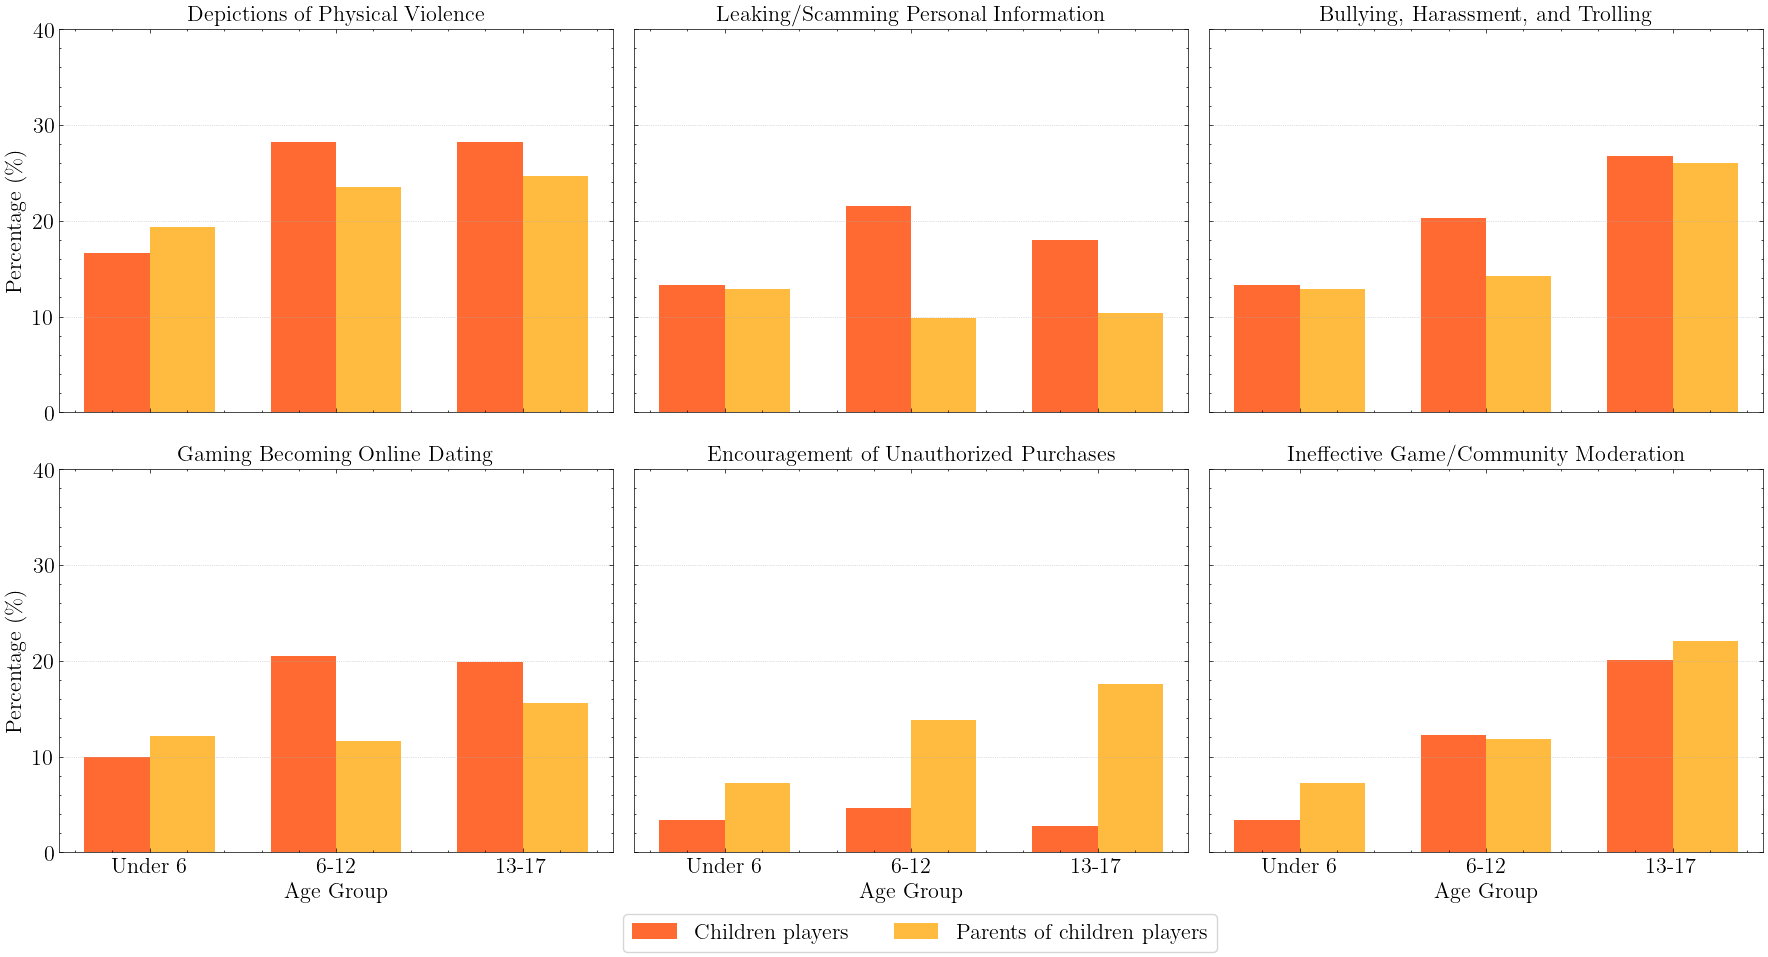

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import scienceplots

plt.style.use('science')

# Set global font sizes (optional but helpful)
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'font.size': 14
})

# Define y-axis formatter to add %
percent_formatter = FuncFormatter(lambda y, _: f'{y:.0f}%')

themes = [
    'Depictions of Physical Violence',
    'Leaking/Scamming Personal Information',
    'Bullying, Harassment, and Trolling',
    'Gaming Becoming Online Dating',
    'Encouragement of Unauthorized Purchases',
    'Ineffective Game/Community Moderation'
]
age_groups = ['Under 6', '6-12', '13-17']
children_data = {
    'Under 6': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12': [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17': [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}
parents_data = {
    'Under 6': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12': [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17': [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

x = np.arange(len(age_groups))
width = 0.35

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

legend_handles = []
legend_labels = []

for i, theme in enumerate(themes):
    ax = axes[i]

    children_vals = [children_data[age][i] for age in age_groups]
    parents_vals = [parents_data[age][i] for age in age_groups]

    child_bars = ax.bar(x - width/2, children_vals, width, label='Children players', color="orangered", alpha=0.8)
    parent_bars = ax.bar(x + width/2, parents_vals, width, label='Parents of children players', color='orange', alpha=0.75)

    if i == 0:
        legend_handles = [child_bars[0], parent_bars[0]]
        legend_labels = ['Children players', 'Parents of children players']

    ax.set_title(theme)
    ax.set_ylim(0, 40)
    ax.set_yticks(np.arange(0, 41, 10))
    ax.yaxis.set_major_formatter(percent_formatter)
    ax.set_xticks(x)

    if i >= 3:
        ax.set_xticklabels(age_groups)
        ax.set_xlabel('Age Group')
    else:
        ax.set_xticklabels([])

    if i % 3 == 0:
        ax.set_ylabel('Percentage (\%)')
    else:
        ax.set_yticklabels([])

    ax.yaxis.grid(True, linestyle='dotted', alpha=0.8)
    ax.xaxis.grid(False)

# Global legend below all plots
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=2, fontsize=16, frameon=True, bbox_to_anchor=(0.52, 0.02))

# Adjust layout
fig.tight_layout(rect=[0, 0.06, 1, 1])

# Save to PDF
plt.savefig('age_risk_distribution.pdf', dpi=300)
plt.show()


## Statistic Anlaysis

Data:

Comments for children in 0-5: 30, 6-12: 498, 13-17: 456
Comments for parents 0-5: 124, 6-12: 533, 13-17: 213

Distribution:

children_data = {
    'Under 6': [16.67%, 13.33%, 13.33%, 10.00%, 3.33%, 3.33%],

    '6-12': [28.18%, 21.58%, 20.29%, 20.45%, 4.67%, 12.24%],

    '13-17': [28.23%, 18.02%, 26.73%, 19.82%, 2.70%, 20.12%]

}

parents_data = {
    'Under 6': [19.35%, 12.90%, 12.90%, 12.10%, 7.26%, 7.26%],

    '6-12': [23.48%, 9.80%, 14.19%, 11.66%, 13.85%, 11.82%],

    '13-17': [24.68%, 10.39%, 25.97%, 15.58%, 17.53%, 22.08%]

}

For each of the six risk category: 

(1) are there any significant differences between parents’ perspectives across age groups?

(2) are there any significant differences between children’s perspectives across age groups?

(3) are there any significant differences between user perspectives overall (children and parents combined) across age groups?

(4) are there any significant differences between children’s perspective and parents’ perspective in the same age group?


1. For the parents

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# -------------------------
# 1) Input data
# -------------------------
themes = [
    'Depictions of Physical Violence',
    'Leaking/Scamming Personal Information',
    'Bullying, Harassment, and Trolling',
    'Gaming Becoming Online Dating',
    'Encouragement of Unauthorized Purchases',
    'Ineffective Game/Community Moderation'
]
age_groups = ['Under 6', '6-12', '13-17']

parent_totals = {'Under 6': 124, '6-12': 533, '13-17': 213}

parents_data = {
    'Under 6': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12':    [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17':   [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

# -------------------------
# 2) Helper function: convert % -> integer counts
# -------------------------
def pct_to_count(percent, total):
    return int(round(percent / 100.0 * total))

# -------------------------
# 3) Build counts and run chi-square per risk
# -------------------------
rows = []
for i, theme in enumerate(themes):
    counts = []
    for age in age_groups:
        count = pct_to_count(parents_data[age][i], parent_totals[age])
        counts.append(count)
    
    # Construct contingency table: rows = age groups, cols = [mentions, non-mentions]
    table = np.array([
        [counts[0], parent_totals['Under 6'] - counts[0]],
        [counts[1], parent_totals['6-12'] - counts[1]],
        [counts[2], parent_totals['13-17'] - counts[2]]
    ])
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    rows.append({
        "Risk": theme,
        "Counts (Under 6)": f"{table[0,0]}/{parent_totals['Under 6']}",
        "Counts (6-12)":    f"{table[1,0]}/{parent_totals['6-12']}",
        "Counts (13-17)":   f"{table[2,0]}/{parent_totals['13-17']}",
        "Chi2": chi2,
        "p-value": p
    })

results_df_parent = pd.DataFrame(rows)2

In [52]:
results_df_parent

,Risk,Counts (Under 6),Counts (6-12),Counts (13-17),Chi2,p-value
0,Depictions of Physical Violence,24/124,125/533,53/213,1.385516,0.500195
1,Leaking/Scamming Personal Information,16/124,52/533,22/213,1.074351,0.584397
2,"Bullying, Harassment, and Trolling",16/124,76/533,55/213,16.132302,0.000314
3,Gaming Becoming Online Dating,15/124,62/533,33/213,2.092826,0.351195
4,Encouragement of Unauthorized Purchases,9/124,74/533,37/213,6.750311,0.034213
5,Ineffective Game/Community Moderation,9/124,63/533,47/213,18.578731,0.000092


In [18]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# store the numbers in a dataframe
df_stat = []
for i, theme in enumerate(themes):
    for age in age_groups:
        df_stat.append({"Risk": theme, "Age": age, "Group": "Parents", "Value": parents_data[age][i]})
        df_stat.append({"Risk": theme, "Age": age, "Group": "Children", "Value": children_data[age][i]})
df_stat = pd.DataFrame(df_stat)


2. For each risk, are there any significant differences between children's perspectives across age groups?

In [53]:
import numpy as np
from scipy.stats import chi2_contingency

# Children comments per group
children_counts = {'Under 6': 30, '6-12': 498, '13-17': 456}

# Children distribution percentages
children_data = {
    'Under 6': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12': [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17': [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}

themes = [
    'Depictions of Physical Violence',
    'Leaking/Scamming Personal Information',
    'Bullying, Harassment, and Trolling',
    'Gaming Becoming Online Dating',
    'Encouragement of Unauthorized Purchases',
    'Ineffective Game/Community Moderation'
]

results = {}

for i, theme in enumerate(themes):
    # build contingency table for this theme
    table = []
    for group, n in children_counts.items():
        mentions = round(n * children_data[group][i] / 100)
        non_mentions = n - mentions
        table.append([mentions, non_mentions])
    chi2, p, dof, exp = chi2_contingency(table)
    results[theme] = (chi2, p, dof)

for theme, (chi2, p, dof) in results.items():
    print(f"{theme}: chi2({dof}) = {chi2:.2f}, p = {p:.4f}")

Depictions of Physical Violence: chi2(2) = 1.93, p = 0.3813
Leaking/Scamming Personal Information: chi2(2) = 2.63, p = 0.2688
Bullying, Harassment, and Trolling: chi2(2) = 7.27, p = 0.0263
Gaming Becoming Online Dating: chi2(2) = 1.96, p = 0.3753
Encouragement of Unauthorized Purchases: chi2(2) = 2.68, p = 0.2625
Ineffective Game/Community Moderation: chi2(2) = 14.89, p = 0.0006


3. For each risk, are there significant differences between user perspectives overall (children + parents combined) across age groups?

In [47]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

children_totals = {'Under 6': 30, '6-12': 498, '13-17': 456}
parent_totals   = {'Under 6': 124, '6-12': 533, '13-17': 213}

# -------------------------
# convert % -> integer counts
# -------------------------
def pct_to_count(percent, total):
    # Round to nearest integer; clamp within [0, total] just in case
    c = int(round(percent / 100.0 * total))
    return min(max(c, 0), total)

# -------------------------
# Build combined counts and run chi-square per risk
# -------------------------
rows = []
for i, theme in enumerate(themes):
    # Combine children + parents counts for each age group
    combined_mentions = []
    combined_nonmentions = []
    for age in age_groups:
        child_m = pct_to_count(children_data[age][i], children_totals[age])
        par_m   = pct_to_count(parents_data[age][i],  parent_totals[age])
        mentions = child_m + par_m
        total_age = children_totals[age] + parent_totals[age]
        nonmentions = total_age - mentions

        combined_mentions.append(mentions)
        combined_nonmentions.append(nonmentions)

    # 3x2 contingency: rows=ages, cols=[mentions, nonmentions]
    table = np.array([
        [combined_mentions[0], combined_nonmentions[0]],  # Under 6
        [combined_mentions[1], combined_nonmentions[1]],  # 6-12
        [combined_mentions[2], combined_nonmentions[2]],  # 13-17
    ])

    chi2, p, dof, expected = chi2_contingency(table)  # no Yates correction for >2x2

    # Save result + readable counts
    rows.append({
        "Risk": theme,
        "Chi2": chi2,
        "p-value": p,
        "DoF": dof,
        "Counts (Under 6)": f"{table[0,0]} mentions / {table[0,1]} non",
        "Counts (6-12)":    f"{table[1,0]} mentions / {table[1,1]} non",
        "Counts (13-17)":   f"{table[2,0]} mentions / {table[2,1]} non",
    })

results_df = pd.DataFrame(rows).sort_values("p-value")
print(results_df.to_string(index=False))

def sig(star_p):
    if star_p < 0.001: return "***"
    if star_p < 0.01:  return "**"
    if star_p < 0.05:  return "*"
    return ""

results_df["Signif"] = results_df["p-value"].apply(sig)


                                   Risk      Chi2      p-value  DoF      Counts (Under 6)          Counts (6-12)         Counts (13-17)
  Ineffective Game/Community Moderation 33.802039 4.570677e-08    2 10 mentions / 144 non 124 mentions / 907 non 139 mentions / 530 non
     Bullying, Harassment, and Trolling 27.127912 1.286023e-06    2 20 mentions / 134 non 177 mentions / 854 non 177 mentions / 492 non
        Depictions of Physical Violence  4.600793 1.002191e-01    2 29 mentions / 125 non 265 mentions / 766 non 182 mentions / 487 non
          Gaming Becoming Online Dating  4.585390 1.009939e-01    2 18 mentions / 136 non 164 mentions / 867 non 123 mentions / 546 non
Encouragement of Unauthorized Purchases  3.090571 2.132510e-01    2 10 mentions / 144 non  97 mentions / 934 non  49 mentions / 620 non
  Leaking/Scamming Personal Information  0.678195 7.124130e-01    2 20 mentions / 134 non 159 mentions / 872 non 104 mentions / 565 non


In [48]:
results_df

,Risk,Chi2,p-value,DoF,Counts (Under 6),Counts (6-12),Counts (13-17),Signif
5,Ineffective Game/Community Moderation,33.802039,4.570677e-08,2,10 mentions / 144 non,124 mentions / 907 non,139 mentions / 530 non,***
2,"Bullying, Harassment, and Trolling",27.127912,1.286023e-06,2,20 mentions / 134 non,177 mentions / 854 non,177 mentions / 492 non,***
0,Depictions of Physical Violence,4.600793,1.002191e-01,2,29 mentions / 125 non,265 mentions / 766 non,182 mentions / 487 non,
3,Gaming Becoming Online Dating,4.585390,1.009939e-01,2,18 mentions / 136 non,164 mentions / 867 non,123 mentions / 546 non,
4,Encouragement of Unauthorized Purchases,3.090571,2.132510e-01,2,10 mentions / 144 non,97 mentions / 934 non,49 mentions / 620 non,
1,Leaking/Scamming Personal Information,0.678195,7.124130e-01,2,20 mentions / 134 non,159 mentions / 872 non,104 mentions / 565 non,


We further conducted chi-square analyses across age groups for the top risks. Significant differences were observed for ineffective game/community moderation ($\chi^2=33.80$, $p<0.001$) and bullying, harassment, and trolling ($\chi^2=27.13$, $p<0.001$), with both risks increasingly emphasized in older groups, suggesting heightened recognition of these challenges during later developmental stages. In contrast, no significant variation across age groups was found for depictions of physical violence ($\chi^2=4.60$, $p=0.10$), gaming becoming online dating ($\chi^2=4.59$, $p=0.10$), encouragement of unauthorized purchases ($\chi^2=3.09$, $p=0.21$), or leaking/scamming personal information ($\chi^2=0.68$, $p=0.71$). These findings indicate that while the perception of most risks remains relatively stable across ages, concerns about moderation and bullying emerge as particularly salient and age-dependent.

4. For each risk, are there any significant differences between children’s perspective and parents’ perspective in the same age group?

In [39]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Total comments
children_totals = {"Under 6": 30, "6-12": 498, "13-17": 456}
parent_totals   = {"Under 6": 124, "6-12": 533, "13-17": 213}

# Percentages
children_data = {
    'Under 6': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12':    [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17':   [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}
parents_data = {
    'Under 6': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12':    [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17':   [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

themes = [
    'Depictions of Physical Violence',
    'Leaking/Scamming Personal Information',
    'Bullying, Harassment, and Trolling',
    'Gaming Becoming Online Dating',
    'Encouragement of Unauthorized Purchases',
    'Ineffective Game/Community Moderation'
]

results = []

for age in ["Under 6", "6-12", "13-17"]:
    for i, theme in enumerate(themes):
        # Convert percentages → counts
        child_mentions = round(children_data[age][i] / 100 * children_totals[age])
        parent_mentions = round(parents_data[age][i] / 100 * parent_totals[age])
        
        child_non = children_totals[age] - child_mentions
        parent_non = parent_totals[age] - parent_mentions
        
        # 2×2 table
        table = [[child_mentions, child_non],
                 [parent_mentions, parent_non]]
        
        chi2, p, _, _ = chi2_contingency(table)
        p = round(p, 4)

        results.append({
            "Age": age,
            "Risk": theme,
            "Child %": children_data[age][i],
            "Parent %": parents_data[age][i],
            "Chi2": chi2,
            "p-value": p
        })

results_df = pd.DataFrame(results)

In [40]:
results_df

,Age,Risk,Child %,Parent %,Chi2,p-value
0,Under 6,Depictions of Physical Violence,16.67,19.35,0.006041,0.9380
1,Under 6,Leaking/Scamming Personal Information,13.33,12.90,0.000000,1.0000
2,Under 6,"Bullying, Harassment, and Trolling",13.33,12.90,0.000000,1.0000
3,Under 6,Gaming Becoming Online Dating,10.00,12.10,0.000017,0.9967
4,Under 6,Encouragement of Unauthorized Purchases,3.33,7.26,0.136872,0.7114
5,Under 6,Ineffective Game/Community Moderation,3.33,7.26,0.136872,0.7114
6,6-12,Depictions of Physical Violence,28.18,23.48,2.689020,0.1010
7,6-12,Leaking/Scamming Personal Information,21.58,9.80,26.265441,0.0000
8,6-12,"Bullying, Harassment, and Trolling",20.29,14.19,6.149270,0.0131
9,6-12,Gaming Becoming Online Dating,20.45,11.66,14.418873,0.0001


The chi-square tests reveal distinct differences between children’s and parents’ perspectives across age groups. For the youngest group (under 6), no significant differences were observed, suggesting that both children and parents share similar concerns at this early stage. In contrast, in the 6–12 group, substantial divergences emerged: children were significantly more likely to report risks related to leaking/scamming personal information, bullying and harassment, and gaming becoming online dating, while parents emphasized encouragement of unauthorized purchases. Among adolescents (13–17), the gap narrowed, with both groups reporting similar levels of concern for violence, bullying, dating, and moderation, though parents continued to stress unauthorized purchases while children highlighted scamming. Overall, these findings indicate that divergences in perspectives are most pronounced in middle childhood, when children emphasize interpersonal and experiential risks while parents focus more on financial and systemic risks.